In [27]:
import glob
import json
import os
import pandas as pd
import numpy as np
from pathlib import Path
import jinja2
from IPython.display import display, HTML


In [2]:
def set_project_root(marker="main.py"):
    """
    Finds the project root by searching upwards for a specific marker
    and sets the current working directory.
    """
    current_dir = Path.cwd()

    # Iterate through the current directory and all its parents
    for path in [current_dir, *current_dir.parents]:
        if (path / marker).exists():
            os.chdir(path)
            print(f"Working directory set to: {path}")
            return path

    print(f"Marker '{marker}' not found. Working directory remains: {current_dir}")
    return current_dir

# Execute the function
set_project_root()

Working directory set to: /home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output


PosixPath('/home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output')

In [3]:
def find_failing_queries_per_template(file_path):
    """
    Counts the number of failed queries per template in a JSON file.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        dict: A dictionary mapping template names to their failure counts.
    """
    failure_counts = {}

    with open(file_path, 'r') as file:
        data = json.load(file)

    for entry in data:
        if "error" in entry:
            # Safely navigate the nested dictionary
            template = entry.get("sequenceElement", {}).get("template")

            if template:
                # Initialize to 0 if template is new, then add 1
                failure_counts[template] = failure_counts.get(template, 0) + 1

    return dict(sorted(failure_counts.items()))


def compare_failures_across_files(directory_path):
    """
    Reads all .json files in a directory, extracts failure counts,
    and returns a pandas DataFrame for comparison.
    """
    all_results = {}

    # Locate all JSON files in the target directory
    file_pattern = os.path.join(directory_path, '*.json')
    json_files = glob.glob(file_pattern)

    for file_path in json_files:
        file_name = os.path.basename(file_path)
        # Extract failure counts for the current file
        counts = find_failing_queries_per_template(file_path)
        all_results[file_name] = counts

    # Convert the nested dictionary to a DataFrame
    # This automatically aligns the templates (rows) and files (columns)
    df = pd.DataFrame(all_results)

    # Replace NaN values with 0 and convert to integers
    df = df.fillna(0).astype(int)

    # Sort the index (templates) alphabetically
    df = df.sort_index()

    return df

def find_failing_queries(file_path, target_template):
    """
    Extracts failing queries for a specific template from a JSON file.

    Args:
        file_path (str): The path to the JSON file.
        target_template (str): The template name to filter by (e.g., 'interactive-discover-8').

    Returns:
        list: A list of dictionaries representing the failing queries.
    """
    # Load the JSON data
    with open(file_path, 'r') as file:
        data = json.load(file)

    failing_queries = []

    # Iterate through entries and filter
    for entry in data:
        if "error" in entry:
            sequence_element = entry.get("sequenceElement", {})
            template = sequence_element.get("template")

            if template == target_template:
                # Remove the clutter
                entry.pop("sequenceInstantiationCounts")
                failing_queries.append(entry)

    return failing_queries


In [4]:
failing_queries_all_runs = compare_failures_across_files("data")
failing_queries_all_runs

,query-results-raw-cache-s.json,query-results-raw-query-cache-n-b-l.json,query-results-raw-default-n-b.json,query-results-raw-query-cache-estimate-n-b-l.json,query-results-raw-query-cache-estimate-n-b-m.json,query-results-raw-cache-n-b-l.json,query-results-raw-default.json,query-results-raw-cache-n-b-s.json,query-results-raw-query-cache-estimate-n-b-s.json,query-results-raw-cache-m.json,query-results-raw-cache-l.json,query-results-raw-query-cache-n-b-s.json,query-results-raw-cache-n-b-m.json,query-results-raw-query-cache-n-b-m.json
interactive-discover-1,2,0,1,0,0,1,3,0,3,4,5,1,2,1
interactive-discover-2,3,0,4,7,3,2,4,3,2,2,4,4,0,0
interactive-discover-3,8,1,6,0,2,1,4,2,2,4,4,4,4,1
interactive-discover-4,20,20,21,21,23,20,21,21,20,23,21,22,20,22
interactive-discover-5,92,92,91,90,91,90,90,91,90,90,95,90,91,90
interactive-discover-6,71,69,70,69,68,71,70,68,69,71,76,70,69,71
interactive-discover-7,100,101,100,100,100,101,99,100,100,101,99,100,100,101
interactive-discover-8,14,71,10,131,126,30,10,31,126,16,15,74,30,70
interactive-short-1,5,1,1,1,3,2,0,2,0,3,2,1,2,2
interactive-short-2,99,100,100,100,100,100,100,100,100,100,100,100,100,100


In [5]:
# Investigate large number of errors with estimate cache on interactive-discover-8
failing_discover_8_cache_estimate_n_b_l = find_failing_queries("data/query-results-raw-query-cache-estimate-n-b-l.json", "interactive-discover-8")
failing_discover_8_cache_estimate_n_b_l

[{'name': 'sequence_0',
  'id': '9',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 185040,
  'timestamps': [],
  'httpRequests': 665,
  '@comunica/persistent-cache-manager:sourceStateQuerySource': '{"hits":10,"misses":571,"evictions":2528,"evictionsCalculatedSize":429484,"evictionPercentage":122.70971428571428}',
  'error': 'Unexpected "!" at position 0 in state STOP',
  'user': {'user': 'http://solidbench-server:3000/pods/00000000000000000933/profile/card#me',
   'transitionProbability': 0.09954255358650524},
  'sequenceLength': 28,
  'sequenceElement': {'session': {'task': 'Messages Person',
    'sessionLength': 16,
    'sessionId': 3},
   'template': 'interactive-discover-8',
   'nOpenSessions': 1,
   'refinementMetadata': {}}},
 {'name': 'sequence_0',
  'id': '9',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 185097,
  'timestamps': [],
  'httpRequests': 775,
  '@comunica/persistent-cache-manager:sourceStateQuerySource': '{"hits":

In [6]:
# Compare to failures with default
failing_discover_8_default= find_failing_queries("data/query-results-raw-default.json",
                                                               "interactive-discover-8")
failing_discover_8_default


[{'name': 'sequence_7',
  'id': '26',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 201029,
  'timestamps': [],
  'httpRequests': 137,
  'error': 'Unexpected "!" at position 0 in state STOP',
  'user': {'user': 'http://solidbench-server:3000/pods/00000021990232556027/profile/card#me',
   'transitionProbability': 0.11674512952701303},
  'sequenceLength': 21,
  'sequenceElement': {'session': {'task': 'Attributes Person',
    'sessionLength': 7,
    'sessionId': 5},
   'template': 'interactive-discover-8',
   'nOpenSessions': 2,
   'refinementMetadata': {'patternIds': [6, 7, 4, 0]}}},
 {'name': 'sequence_7',
  'id': '26',
  'hash': 'd41d8cd98f00b204e9800998ecf8427e',
  'results': 0,
  'time': 205241,
  'timestamps': [],
  'httpRequests': 117,
  'error': 'Unexpected "!" at position 0 in state STOP',
  'user': {'user': 'http://solidbench-server:3000/pods/00000021990232556027/profile/card#me',
   'transitionProbability': 0.11674512952701303},
  'sequenceLength': 21,

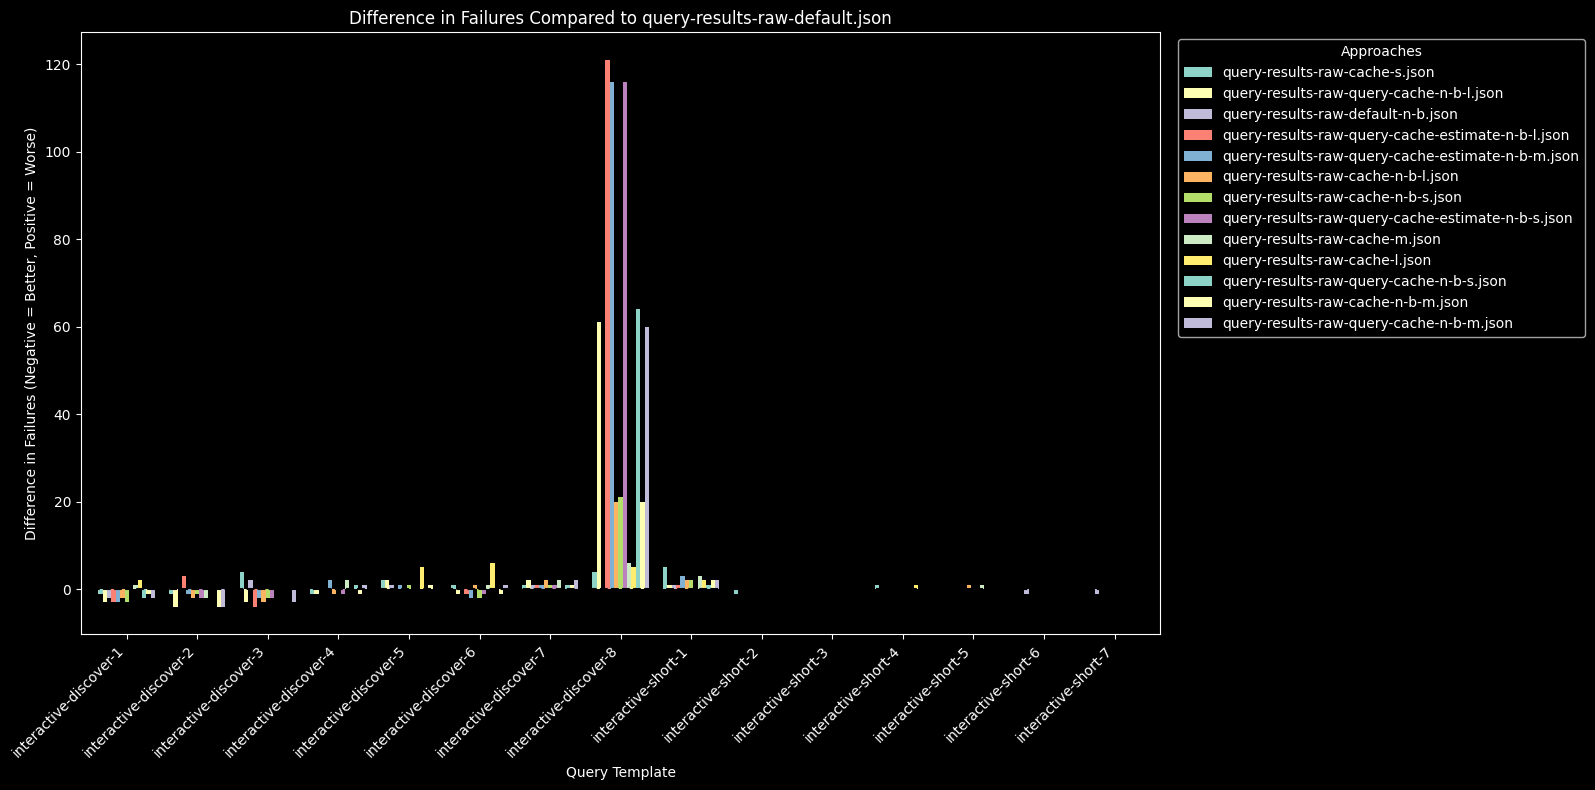

In [7]:
from matplotlib import pyplot as plt

def plot_baseline_differences(df, baseline_column):
    """
    Plots the difference in failure counts between various approaches and a baseline
    using a vertical grouped bar chart.
    """
    if baseline_column not in df.columns:
        raise ValueError(f"Baseline '{baseline_column}' not found.")

    # Calculate the difference from the baseline
    df_diff = df.drop(columns=[baseline_column]).subtract(df[baseline_column], axis=0)

    # Create a vertical grouped bar chart with a wider figure size
    fig, ax = plt.subplots(figsize=(16, 8))
    df_diff.plot(kind='bar', ax=ax, width=0.8)

    # Add a horizontal line at 0 to mark the baseline
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Formatting
    ax.set_title(f'Difference in Failures Compared to {baseline_column}')
    ax.set_ylabel('Difference in Failures (Negative = Better, Positive = Worse)')
    ax.set_xlabel('Query Template')

    # Rotate x-axis labels to ensure readability
    plt.xticks(rotation=45, ha='right')

    # Place legend outside the plot area
    ax.legend(title='Approaches', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_baseline_differences(failing_queries_all_runs, "query-results-raw-default.json")

In [ ]:
# Get the per template execution time and hit rate
import os
import json
import pandas as pd
import numpy as np

def generate_comparison_dfs_pooled(files):
    """
    Parses result files, pools variance across specific query instantiations
    identified by template, name, and id, and generates a DataFrame for each cache type.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        records = []
        for entry in data:
            template = entry.get("sequenceElement", {}).get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                        entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    total = hits + cache_stats.get("misses", 0)
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            # Ensure all composite keys exist before appending
            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000,
                    'hit_rate': hit_rate
                })

        if not records:
            continue

        df_records = pd.DataFrame(records)

        # Calculate variance and mean per exact instantiation (template + name + id)
        inst_stats = df_records.groupby(['template', 'name', 'id']).agg(
            n=('time_s', 'count'),
            var_time=('time_s', 'var'),
            mean_time=('time_s', 'mean'),
            mean_hr=('hit_rate', 'mean')
        ).reset_index()

        inst_stats['var_time'] = inst_stats['var_time'].fillna(0)

        # 3. Pool the metrics up to the template level
        def pool_metrics(group):
            total_weight = (group['n'] - 1).sum()
            if total_weight > 0:
                pooled_var = ((group['n'] - 1) * group['var_time']).sum() / total_weight
            else:
                pooled_var = 0.0

            return pd.Series({
                'Avg Time (s)': group['mean_time'].mean(),
                'Std Time (s)': np.sqrt(pooled_var),
                'Avg Hit Rate': group['mean_hr'].mean()
            })

        template_metrics = inst_stats.groupby('template').apply(pool_metrics, include_groups=False).to_dict('index')
        all_results[label] = template_metrics

    # 4. Group by cache type
    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results.get(algo, {}).get(tmpl, {}).get(metric, np.nan)
                             for tmpl in all_results.get(algo, {})}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Std Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def generate_comparison_dfs(files):
    """
    Parses result files and generates a separate DataFrame for each cache type,
    comparing its sizes against the default baselines.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        template_data = {}
        for entry in data:
            template = entry.get("sequenceElement", {}).get("template")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState")
            if not cache_str:
                cache_str = entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    misses = cache_stats.get("misses", 0)
                    total = hits + misses
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            if template and exec_time is not None:
                if template not in template_data:
                    template_data[template] = {'times': [], 'hit_rates': []}
                template_data[template]['times'].append(exec_time)
                if not np.isnan(hit_rate):
                    template_data[template]['hit_rates'].append(hit_rate)

        avg_metrics = {}
        for tmpl, metrics in template_data.items():
            avg_time = (sum(metrics['times']) / len(metrics['times'])) / 1000
            avg_hr = sum(metrics['hit_rates']) / len(metrics['hit_rates']) if metrics['hit_rates'] else np.nan
            avg_metrics[tmpl] = {'Avg Time (s)': avg_time, 'Avg Hit Rate': avg_hr}

        all_results[label] = avg_metrics

    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue

        # Extract cache type assuming format: {cache_type}-{size}
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    # Create a DataFrame for each cache type
    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        # Sort labels by size: -s, -m, -l
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results[algo][tmpl].get(metric, np.nan) for tmpl in all_results[algo]}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def display_comparison_dfs(dfs_dict):
    """
    Iterates through the dictionary and displays each DataFrame
    as an HTML table with a clear heading.
    """
    for cache_type, df in dfs_dict.items():
        # Print a clear heading for the cache type
        display(HTML(f"<h3>Cache Type: {cache_type.upper()}</h3>"))

        # Display the actual DataFrame
        display(df)

files = glob.glob("data/*.json")
df_avg_times = generate_comparison_dfs_pooled(files)
display_comparison_dfs(df_avg_times)

                   template        name  id  time_s  hit_rate
3    interactive-discover-1  sequence_0   7   0.863  1.000000
13   interactive-discover-1  sequence_0  22   0.646  1.000000
14   interactive-discover-1  sequence_0  23   1.145  0.322404
15   interactive-discover-1  sequence_0  24   0.685  1.000000
16   interactive-discover-1  sequence_0  25   0.564  1.000000
23   interactive-discover-1  sequence_0  34   3.490  1.000000
27   interactive-discover-1  sequence_0   7   1.081  1.000000
37   interactive-discover-1  sequence_0  22   0.628  1.000000
38   interactive-discover-1  sequence_0  23   1.105  0.322404
39   interactive-discover-1  sequence_0  24   0.622  1.000000
40   interactive-discover-1  sequence_0  25   0.550  1.000000
47   interactive-discover-1  sequence_0  34   3.800  1.000000
51   interactive-discover-1  sequence_0   7   1.217  1.000000
60   interactive-discover-1  sequence_0  22   0.621  1.000000
61   interactive-discover-1  sequence_0  23   1.049  0.322404
62   int

KeyboardInterrupt: 